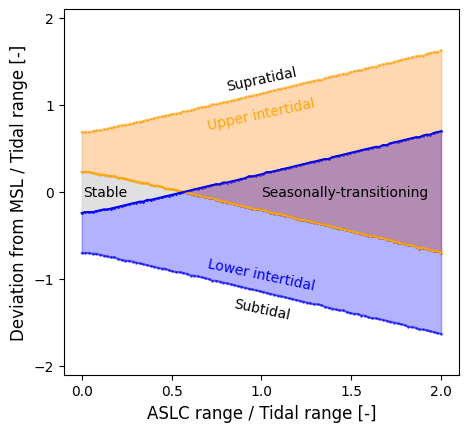

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import src.functions as f

def figure_2a(ax, path_bin = './bin/figure_2/figure_2a-alt.npy', run = False):

    def run_simulation_figure_2(path_bin):

        def identify_intertidal_zones(elevation, amplitude_annual_cycle, n_years):

            def closest_to(x, seq):
                return np.argmin(np.abs(seq - x))

            _, water_level, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle, n_years = n_years, sigma = 0.013, rho = 0.079)
            _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
            emergence_freq, inundation_freq = f.calculate_inundation_metrics(elevation, low_waterlevel, high_waterlevel)

            supratidal_boundary = elevation[closest_to(0.01, inundation_freq)]
            upper_intertidal_boundary = elevation[closest_to(0.99, inundation_freq)]
            lower_intertidal_boundary = elevation[closest_to(0.99, emergence_freq)]
            subtidal_boundary = elevation[closest_to(0.01, emergence_freq)]

            return supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary

        n_years = 20
        ntrials = 100
        elevation = np.arange(-2, 2, 0.01)
        amplitude_annual_cycle = np.linspace(0, 2.0, ntrials)
        supratidal_boundary       = np.array([np.nan]*ntrials)
        upper_intertidal_boundary = np.array([np.nan]*ntrials)
        lower_intertidal_boundary = np.array([np.nan]*ntrials)
        subtidal_boundary         = np.array([np.nan]*ntrials)
        for i in range(ntrials):
            supratidal_boundary[i], upper_intertidal_boundary[i], lower_intertidal_boundary[i], subtidal_boundary[i] = identify_intertidal_zones(elevation, amplitude_annual_cycle[i], n_years)
            print(i)

        np.save(path_bin, (amplitude_annual_cycle, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary))

    def plot_figure_2(ax,path_bin):

        amplitude_annual_cycle, supratidal_boundary, upper_intertidal_boundary, lower_intertidal_boundary, subtidal_boundary = np.load(path_bin)

        # Figure 2b
        ax.plot(amplitude_annual_cycle, supratidal_boundary, c = 'orange', alpha = 0.5)
        ax.plot(amplitude_annual_cycle, upper_intertidal_boundary, c = 'orange')
        ax.plot(amplitude_annual_cycle, lower_intertidal_boundary, c = 'blue')
        ax.plot(amplitude_annual_cycle, subtidal_boundary, c = 'blue', alpha = 0.5)
        ax.scatter(amplitude_annual_cycle, supratidal_boundary, c = 'orange', s = 1, alpha = 0.5)
        ax.scatter(amplitude_annual_cycle, upper_intertidal_boundary, c = 'orange', s = 1, alpha = 1.0)
        ax.scatter(amplitude_annual_cycle, lower_intertidal_boundary, c = 'blue', s = 1, alpha = 1.0)
        ax.scatter(amplitude_annual_cycle, subtidal_boundary, c = 'blue', s = 1, alpha = 0.5)

        def closest_to(x, seq):
            return np.argmin(np.abs(seq - x))
        
        transition_point = amplitude_annual_cycle[closest_to(upper_intertidal_boundary, 0)]
        plt.rcParams["hatch.linewidth"] = 4
        ax.fill_between(x = amplitude_annual_cycle[amplitude_annual_cycle <= transition_point], 
                        y1 = (upper_intertidal_boundary)[amplitude_annual_cycle <= transition_point], 
                        y2 = (lower_intertidal_boundary)[amplitude_annual_cycle <= transition_point], color = (0.8, 0.8, 0.8, 0.6))
        # ax.fill_between(x = amplitude_annual_cycle[amplitude_annual_cycle > transition_point], 
        #                 y1 = (upper_intertidal_boundary)[amplitude_annual_cycle > transition_point], 
        #                 y2 = (lower_intertidal_boundary)[amplitude_annual_cycle > transition_point], edgecolor = (0.0, 0.0, 1.0, 0.1),   facecolor = (1.0, 0.647, 0.0, 0.1),hatch=r"//")
        ax.fill_between(x = amplitude_annual_cycle[amplitude_annual_cycle > transition_point], 
                        y1 = (upper_intertidal_boundary)[amplitude_annual_cycle > transition_point], 
                        y2 = (lower_intertidal_boundary)[amplitude_annual_cycle > transition_point], color = (0.5, 0.25, 0.5, 0.6))
        ax.fill_between(x = amplitude_annual_cycle, 
                        y1 = (supratidal_boundary), 
                        y2 = np.maximum(lower_intertidal_boundary, upper_intertidal_boundary), color = (1, 0.5, 0, 0.3))
        ax.fill_between(x = amplitude_annual_cycle, 
                        y1 = (subtidal_boundary), 
                        y2 = np.minimum(lower_intertidal_boundary, upper_intertidal_boundary), color = (0, 0, 1, 0.3))

        ax.text(x = amplitude_annual_cycle.max()*0.5, y =  1.30, s = 'Supratidal',       c = 'black',  rotation =  12, fontsize = 10, horizontalalignment = 'center', verticalalignment = 'center')
        ax.text(x = amplitude_annual_cycle.max()*0.5, y =  0.90, s = 'Upper intertidal', c = 'orange', rotation =  12, fontsize = 10, horizontalalignment = 'center', verticalalignment = 'center')
        ax.text(x = amplitude_annual_cycle.max()*0.5, y = -0.95, s = 'Lower intertidal', c = 'blue',   rotation = -12, fontsize = 10, horizontalalignment = 'center', verticalalignment = 'center')
        ax.text(x = amplitude_annual_cycle.max()*0.5, y = -1.35, s = 'Subtidal',         c = 'black',  rotation = -12, fontsize = 10, horizontalalignment = 'center', verticalalignment = 'center')
        ax.text(x = 0.01, y = 0, s = 'Stable',     c = 'black',  rotation =   0, fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center')
        ax.text(x = amplitude_annual_cycle.max() - 0.07, y = 0, s = 'Seasonally-transitioning', c = 'black',  rotation = 0, fontsize = 10, horizontalalignment = 'right', verticalalignment = 'center')
        ax.set_xticks(ticks = [0,0.5,1,1.5,2])
        ax.set_yticks(ticks = [-2,-1,0,1,2])
        ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
        ax.set_xlabel('ASLC range / Tidal range [-]', fontsize = 12)
        ax.set_ylim(-2.1, 2.1)

    if run:
        run_simulation_figure_2(path_bin)
    plot_figure_2(ax,path_bin)

def figure_2c(ax, path_csv = 'data/ticon/TICON.txt',return_output = False):

    def create_ticon_timeseries(path_csv, lat, lon):

        def find_tidal_range(w, dt):

            if dt != 5/60:
                # Interpolate to 5 min measuring interval so 745 min tidal interval can be divided evenly
                t = np.arange(0, w.size, 1) * dt
                tp = np.arange(0, t.max(), 5/60)
                w = np.interp(x = tp, xp = t, fp = w)

            # Reshape water level time series into stacked array of n tidal cycles (each 149 measurements long at dt = 5/60)
            n_measurements_per_tide = int((745/60) / (5/60))
            n_tides = int(np.floor(w.size/n_measurements_per_tide))
            w = w[:int(n_tides*n_measurements_per_tide)]
            w = w.reshape(n_tides, n_measurements_per_tide)

            # Calcualte high & low water level of each tidal cycle, and from that calculate the avg. tidal range
            high_water_level = w.max(axis = 1)
            low_water_level = w.min(axis = 1)
            tidal_range = (high_water_level - low_water_level)

            return tidal_range.mean()

        tidal_constants = np.array([
            'M2', 'K1', 'N2', 'O1', 'P1', 'Q1', 'K2', 'S2', 'S1', 'SA', 'T2', 'MF', 'MM',
            '2N2', 'M4', 'J1', 'SSA', 'MSF', 'MSQ', 'EP2', 'L2', 'M3', 'R2', 'MI2', 'MTM',
            'NI2', 'LM2', 'MN4', 'MS4', 'MKS', 'N4', 'M6', 'M8', 'S4', '2Q1', 'OO1', 'S3',
            'MA2', 'MB2', 'M1'
        ])
        period_hr = np.array([
            12.4206, 23.9345, 12.6583, 25.8193, 24.0659, 26.8684, 11.9672, 12.0000, 24.0000,
            8766.0, 12.0160, 327.85, 661.31, 12.9054, 6.2103, 23.0984, 4383.0, 354.37, 6.1328,
            12.3283, 12.1916, 8.2804, 11.8700, 12.8729, 6.1033, 12.8864, 12.6321, 6.2692,
            6.1033, 6.0769, 6.3293, 4.1402, 3.1052, 6.0000, 27.8454, 22.3061, 8.0000, 12.8714,
            12.5660, 23.9340
        ])

        df = pd.read_csv(path_csv, sep='\s+')
        df.columns = ['latitude', 'longitude', 'tidal_constituent', 'amplitude_cm', 'phase_degrees', 'amplitude-std_cm', 'phase-std_degrees', 'missing_data_percent', 'total_observations', 'time_gap_max', 'start_date', 'end_date', 'data_source']

        df['site_id'] = df.groupby(['latitude', 'longitude', 'data_source', 'start_date', 'end_date']).ngroup()
        site_list = np.unique(df['site_id'])

        def closest_to(x0, y0, x1, y1):
            return np.argmin(np.sqrt((x1 - x0)**2 + (y1 - y0)**2))
        idx = closest_to(df['latitude'], df['longitude'],  lat, lon)

        site = df['site_id'] == df['site_id'][idx]
        df_site = df[site]
        df_site.loc[df['tidal_constituent'] == 'SA', 'amplitude_cm'] = 0 
        df_site.loc[df['tidal_constituent'] == 'SSA', 'amplitude_cm'] = 0 
        amplitude_m  = df_site['amplitude_cm'].to_numpy() / 100
        phase_rad  = np.deg2rad(df_site['phase_degrees'].to_numpy())

        n_years = 2
        dt = 5/60
        tf    = 365.25 * 24 * n_years # 1 year (in hours)
        t = np.arange(0, tf + dt, dt)
        
        w = (amplitude_m[np.newaxis, :] * np.cos(t[:, np.newaxis]*2*np.pi/period_hr[np.newaxis, :] + phase_rad[np.newaxis, :])).sum(axis = 1)
        tidal_range = find_tidal_range(w, dt)

        return t, w, tidal_range

    def generate_aslc(time, amplitude_annual_m, phase):

        period_annual_hr = 365.25 * 24
        annual_sea_level_cycle = amplitude_annual_m * np.cos(time*2*np.pi/period_annual_hr + phase)

        return annual_sea_level_cycle

    def generate_oun(nt, sigma, rho, dt, xmean = 0):

        r = np.random.normal(size = nt)
        x = np.array([np.nan]*nt)
        x[0] = xmean
        for t in range(1, nt):
            x[t] = x[t - 1] + sigma*np.sqrt(dt)*r[t] + rho*(xmean - x[t - 1])*dt

        return x

    def add_boxplot(ax, pos, elevation, emergence_freq, inundation_freq):
    
        dz = np.round(np.diff(elevation).mean(), 3)    
        y_s= []
        for i in range(emergence_freq.shape[0]):
            upper_intertidal         = (emergence_freq [i,:] > 0.99) & ((inundation_freq[i,:] < 0.99) & (inundation_freq[i,:] > 0.01))
            intermediate_intertidal  = (inundation_freq[i,:] > 0.99) & (emergence_freq [i,:] > 0.99)
            lower_intertidal         = ((emergence_freq [i,:] < 0.99) & (emergence_freq [i,:] > 0.01)) & (inundation_freq[i,:] > 0.99)
            transitioning_intertidal = ((inundation_freq[i,:] < 0.99) & (inundation_freq[i,:] > 0.01)) & ((emergence_freq [i,:] < 0.99) & (emergence_freq [i,:] > 0.01))
        
            y = np.cumsum([0, lower_intertidal.sum(), intermediate_intertidal.sum(), transitioning_intertidal.sum(), upper_intertidal.sum()])*dz
            y -= y.max()/2
            y_s.append(y)
            lower = Rectangle((i*0.125 - 0.1 + pos*0.5, y[0]), 0.1, y[1] - y[0], edgecolor = (0.0, 0.0, 1.0, 1),   facecolor = (0.0, 0.0, 1.0, 0.1), lw = 2)
            ax.add_patch(lower)
            if i==1:
                ax.text(i*0.125 + pos*0.5 + .02,y[0]+.5*(y[1] - y[0]),
                        '{0:.1f}'.format(100*((y_s[1][1] - y_s[1][0])-(y_s[0][1] - y_s[0][0]))/(y_s[0][1] - y_s[0][0]))+'%',
                        color=(0.0, 0.0, 1.0, 1))
            
            upper = Rectangle((i*0.125 - 0.1 + pos*0.5, y[3]), 0.1, y[4] - y[3], edgecolor = (1.0, 0.647, 0.0, 1), facecolor = (1.0, 0.647, 0.0, 0.1), lw = 2)
            ax.add_patch(upper)
            plt.rcParams["hatch.linewidth"] = 4
            if (y[2] - y[1]) > 0:
                inter = Rectangle((i*0.125 - 0.1 + pos*0.5, y[1]), 0.1, y[2] - y[1], edgecolor = (0.5, 0.5, 0.5, 1),   facecolor = (0.5, 0.5, 0.5, 0.1), lw = 2)
                ax.add_patch(inter)
            if (y[3] - y[2]) > 0:
                trans = Rectangle((i*0.125 - 0.1 + pos*0.5, y[1]), 0.1, y[3] - y[2], edgecolor = (0.0, 0.0, 1.0, 0.1),   facecolor = (1.0, 0.647, 0.0, 0.1), lw = 2, hatch=r"//")
                ax.add_patch(trans)
            ax.axhline(y=0,color='black',linewidth=.5,linestyle='dashed',zorder=0)
        return y_s
    ax.set_ylim(-4.1, 4.1)
    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks(ticks = [0*0.5,1*0.5,2*0.5], labels = ['Papeete', 'Barcelona', 'Sakai'])
    ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_xlabel('Location', fontsize = 12)
    y_s=[]
    for i in range(3):
    
        if i == 0:
            lat, lon, historical_aslc, future_aslc_change, phase, sigma, rho = -17.533, -149.573, 0.0567, 0.0260, 0.25*2*np.pi, 0.013, 0.079
        elif i == 1:
            lat, lon, historical_aslc, future_aslc_change, phase, sigma, rho =  41.342,    2.166, 0.1160, 0.0282, 0.70*2*np.pi, 0.007, 0.005
        elif i == 2:
            lat, lon, historical_aslc, future_aslc_change, phase, sigma, rho =  35.548,  133.243, 0.3650, 0.0246, 0.65*2*np.pi, 0.010, 0.006

        time, waterlevel, tidal_range = create_ticon_timeseries(path_csv, lat, lon)
        historical_annual_sealevel_cycle = generate_aslc(time, amplitude_annual_m = historical_aslc, phase = phase)
        future_annual_sealevel_cycle = generate_aslc(time, amplitude_annual_m = historical_aslc + future_aslc_change, phase = phase)
        w_stochastic = generate_oun(time.size, sigma, rho, dt = np.diff(time).mean(), xmean = 0)

        # Add components & rescale to tidal range
        waterlevel_t0 = (waterlevel + historical_annual_sealevel_cycle + w_stochastic)/tidal_range
        waterlevel_t1 = (waterlevel + future_annual_sealevel_cycle + w_stochastic)/tidal_range

        dt = np.diff(time).mean()
        _, low_waterlevel_0, high_waterlevel_0 = f.calculate_highlow_water(waterlevel_t0, dt)
        _, low_waterlevel_1, high_waterlevel_1 = f.calculate_highlow_water(waterlevel_t1, dt)
        elevation, emergence_freq_0, inundation_freq_0 = f.calculate_inundation_metrics(low_waterlevel_0, high_waterlevel_0, dz = 0.01)
        _,         emergence_freq_1, inundation_freq_1 = f.calculate_inundation_metrics(low_waterlevel_1, high_waterlevel_1, dz = 0.01)
        emergence_freq = np.vstack((emergence_freq_0, emergence_freq_1))
        inundation_freq = np.vstack((inundation_freq_0, inundation_freq_1))

        y = add_boxplot(ax, i, elevation, emergence_freq, inundation_freq)
        y_s.append(y)
    if return_output:
        return y_s
        
def figure_2_multipanel(path_png = './figures/figure_2/figure_2ac.png'):

    np.random.seed(12345)

    rows, cols = 2, 1
    fig = plt.figure(figsize=((4.8 + 0.3)*cols,(4.8 + 0.3)*rows))
    gs1 = fig.add_gridspec(rows,cols,hspace=.15, wspace=.15) #define subplot grid

    ax = fig.add_subplot(gs1[0,0])
    figure_2a(ax, path_bin = './bin/figure_2/figure_2a-barcelona.npy', run = False)
    # ax = fig.add_subplot(gs1[1,0])
    # figure_2c(ax, path_csv = './data/ticon/TICON.txt')    
    
    # if path_png is not None:
    #     plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

figure_2_multipanel(path_png = './figures/figure_2/figure_2ac.png')